In [1]:
import pandas as pd
import os
import kagglehub
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
import itertools

In [3]:
#Load .env file for Kaggle Credentials
load_dotenv()
username = os.getenv("KAGGLE_USERNAME")
key = os.getenv("KAGGLE_KEY")

os.environ["KAGGLE_USERNAME"] = username
os.environ["KAGGLE_KEY"] = key

In [4]:
#Locate path to the Kaggle dataset
path = kagglehub.dataset_download(
    "aiaiaidavid/the-big-dataset-of-ultra-marathon-running"
)

100%|██████████| 246M/246M [00:02<00:00, 94.2MB/s]

Extracting files...


In [5]:
df = pd.read_csv(f"{path}/TWO_CENTURIES_OF_UM_RACES.csv", encoding="latin1")
df = df.drop(columns=["Event dates", "Athlete club", "Event number of finishers", "Athlete average speed"])

/tmp/ipykernel_1533/80324502.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/TWO_CENTURIES_OF_UM_RACES.csv", encoding="latin1")


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# 1 — PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

# a. Extract recent year data as the timining is more accurate
df = df[df['Year of event'] >= 2000]

# b. Filter for athletes that have a longer career, 10 races yielded best results
threshold_of_races = 10
valid_athletes = df['Athlete ID'].value_counts()
valid_athletes = valid_athletes[valid_athletes > threshold_of_races].index
experienced_df = df[df['Athlete ID'].isin(valid_athletes)]
print(f"Number of experienced athletes: {experienced_df['Athlete ID'].nunique()}")

# c. Extract races of length 50km
df_50km = experienced_df[experienced_df['Event distance/length'] == '50km'].copy()
print(f"Number 50km race entries: {len(df_50km )}")

#Dropping multi-day entries
mask = df_50km ["Athlete performance"].str.contains("d ", na=False)
df_50km  = df_50km [~mask].copy()
df_50km.dropna()

df_50km.sample(5)

Number of experienced athletes: 142777
Number 50km race entries: 637351


,Year of event,Event name,Event distance/length,Athlete performance,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete ID
6161105,2014,Tagaytay To Nasugbu (T2N) 50K Ultra Marathon (...,50km,6:44:38 h,PHI,1987.0,M,M23,704471
5126469,2011,Trail des 5 Moulins (FRA),50km,4:56:47 h,FRA,1963.0,M,M45,581643
185066,2018,Two Oceans Marathon - 50km Split (RSA),50km,5:23:01 h,RSA,1967.0,M,M50,136600
6469615,2015,Blackfoot Ultra 50 Km (CAN),50km,4:11:34 h,CAN,1980.0,M,M35,282629
5790858,2013,Ultramaraton Chudy Wawrzyniec 50 Km (POL),50km,8:25:00 h,POL,1990.0,M,M23,227800


In [7]:
# Drop 0:00:00 h entries before parsing
df_50km = df_50km[df_50km["Athlete performance"] != "0:00:00 h"].copy()

time_parts = df_50km["Athlete performance"].str.replace(" h", "").str.split(":", expand=True)

df_50km["hours"] = (
    time_parts[0].astype(float) +
    time_parts[1].astype(float) / 60 +
    time_parts[2].astype(float) / 3600
)

df_50km["calculated_speed"] = 50 / df_50km["hours"]

# The current world record marathon pace, set by Sabastian Sawe at the 2026 London Marathon (1:59:30), is approximately 21.2 km/h
# Filter both ends — too fast and too slow
df_50km = df_50km[df_50km["calculated_speed"] <= 19].copy() # Ultra-marathons are longer so pace should be slower
df_50km = df_50km[df_50km["calculated_speed"] > 2].copy()  # removes any remaining near-zero speeds

df_50km["finish_time_mins"] = df_50km["hours"] * 60

print(df_50km["calculated_speed"].describe())

count    637328.000000
mean          8.324618
std           2.211014
min           2.044804
25%           6.743341
50%           8.194855
75%           9.694097
max          18.491884
Name: calculated_speed, dtype: float64


In [8]:
threshold = df_50km["calculated_speed"].quantile(0.90)
df_50km = df_50km[df_50km["calculated_speed"] >= threshold].copy()

print(f"Top 10% Entries: {len(df_50km)}\n")
print(df_50km["calculated_speed"].describe())

Top 10% Entries: 63735

count    63735.000000
mean        12.573472
std          1.159537
min         11.245080
25%         11.664831
50%         12.267430
75%         13.155971
max         18.491884
Name: calculated_speed, dtype: float64


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# 2 — FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════
# a. Athlete Age
df_50km["athlete_age"] = df_50km["Year of event"] - df_50km["Athlete year of birth"]

# b. Age squared - captures non-linear age effect (performance peaks then declines)
df_50km["athlete_age_squared"] = df_50km["athlete_age"] ** 2

# c. Gender - binary encode
df_50km["gender_male"] = (df_50km["Athlete gender"] == "M").astype(int)

# e. Age from peak (marathon peak age ~28-32, using 30 as midpoint)
df_50km["age_from_peak"] = abs(df_50km["athlete_age"] - 30)

# f. Experience - log transform to diminish returns of extra races
# log(1 + x) ensures athletes with 0 previous races don't cause log(0)
df_50km["race_count"] = df_50km.groupby("Athlete ID")["Athlete ID"].transform("count")
df_50km["experience_log"] = np.log1p(df_50km["race_count"])


# g. Age x Gender interaction
df_50km["age_gender"] = df_50km["athlete_age"] * df_50km["gender_male"]

# h. Age x log(experience) interaction
df_50km["age_x_experience"] = df_50km["athlete_age"] * df_50km["experience_log"]

# i. Cross-race improvement trend of athlete
df_50km = df_50km.sort_values(["Athlete ID", "Year of event", "Event name"])
df_50km["improvement_trend"] = (
    df_50km.groupby("Athlete ID")["finish_time_mins"]
    .transform(lambda x: x.shift(1) - x.shift(2))
)

# j. Cross-race consistency
df_50km["performance_std"] = (
    df_50km.groupby("Athlete ID")["finish_time_mins"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=2).std())
)

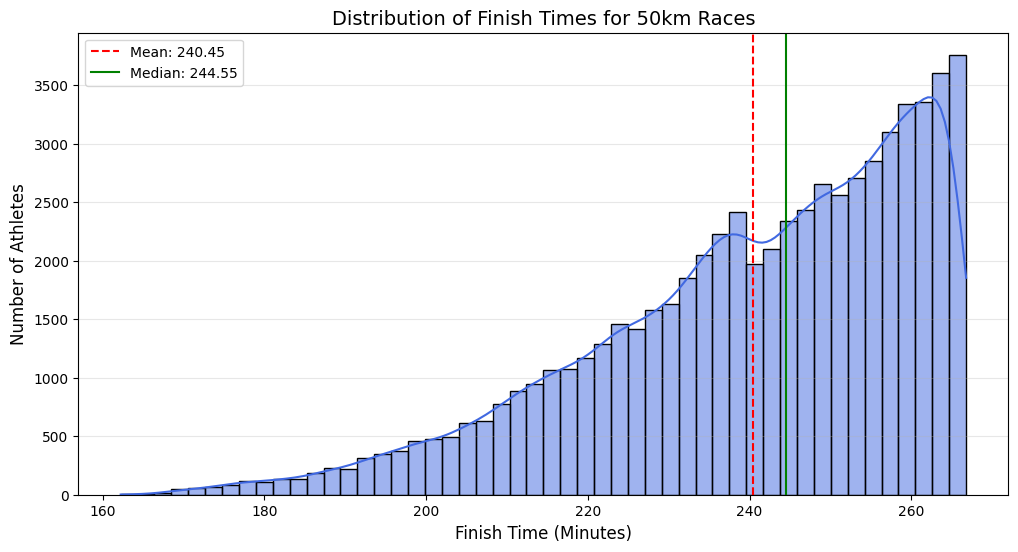

In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(df_50km['finish_time_mins'], kde=True, bins=50, color='royalblue')
plt.axvline(df_50km['finish_time_mins'].mean(), color='red', linestyle='--', label=f"Mean: {df_50km['finish_time_mins'].mean():.2f}")
plt.axvline(df_50km['finish_time_mins'].median(), color='green', linestyle='-', label=f"Median: {df_50km['finish_time_mins'].median():.2f}")

plt.title('Distribution of Finish Times for 50km Races', fontsize=14)
plt.xlabel('Finish Time (Minutes)', fontsize=12)
plt.ylabel('Number of Athletes', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

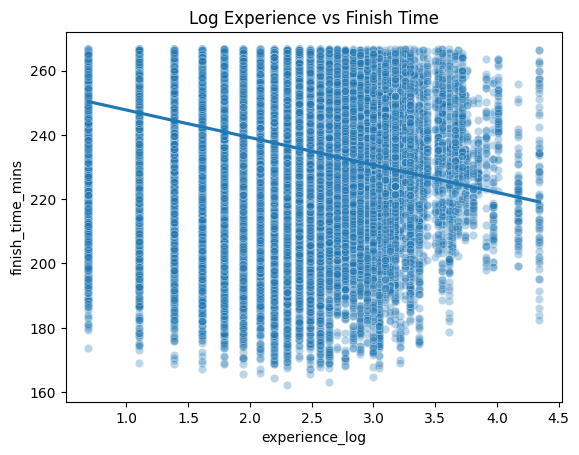

In [11]:
plt.figure()
sns.scatterplot(x="experience_log", y="finish_time_mins", data=df_50km, alpha=0.3)
sns.regplot(x="experience_log", y="finish_time_mins", data=df_50km, scatter=False)
plt.title("Log Experience vs Finish Time")
plt.show()

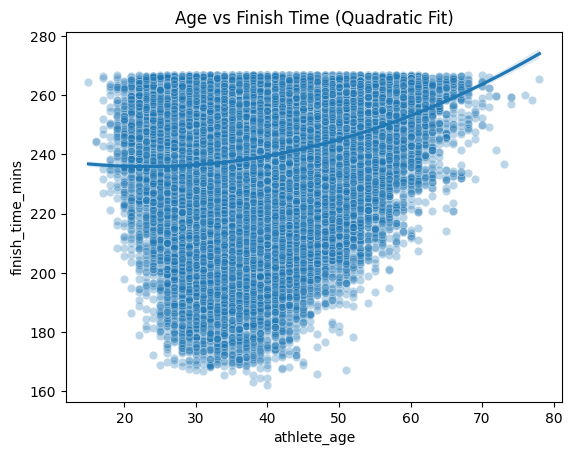

In [12]:
plt.figure()
sns.scatterplot(x="athlete_age", y="finish_time_mins", data=df_50km, alpha=0.3)
sns.regplot(x="athlete_age", y="finish_time_mins", data=df_50km, scatter=False, order=2)
plt.title("Age vs Finish Time (Quadratic Fit)")
plt.show()

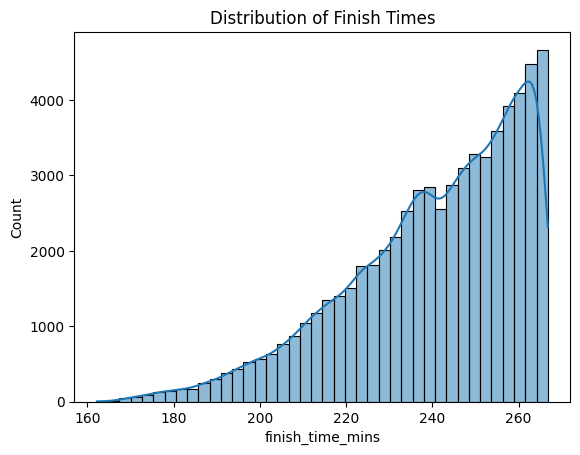

In [13]:
plt.figure()
sns.histplot(df_50km["finish_time_mins"], bins=40, kde=True)
plt.title("Distribution of Finish Times")
plt.show()

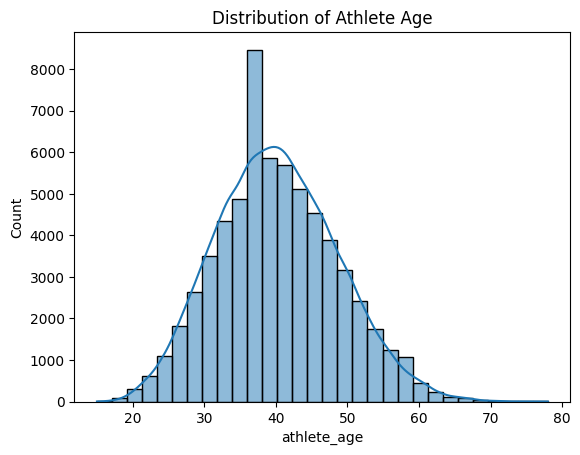

In [14]:
plt.figure()
sns.histplot(df_50km["athlete_age"], bins=30, kde=True)
plt.title("Distribution of Athlete Age")
plt.show()

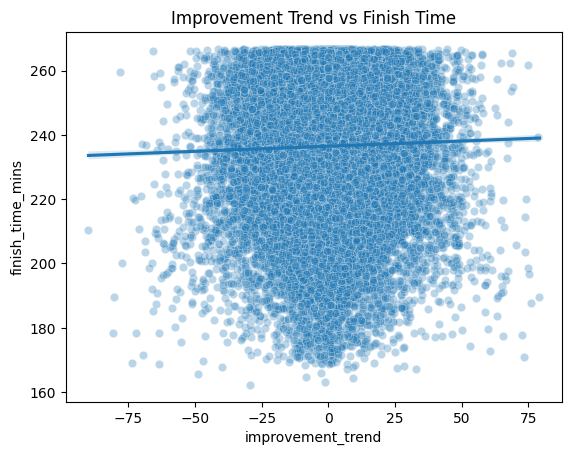

In [15]:
plt.figure()
sns.scatterplot(x="improvement_trend", y="finish_time_mins", data=df_50km, alpha=0.3)
sns.regplot(x="improvement_trend", y="finish_time_mins", data=df_50km, scatter=False)
plt.title("Improvement Trend vs Finish Time")
plt.show()

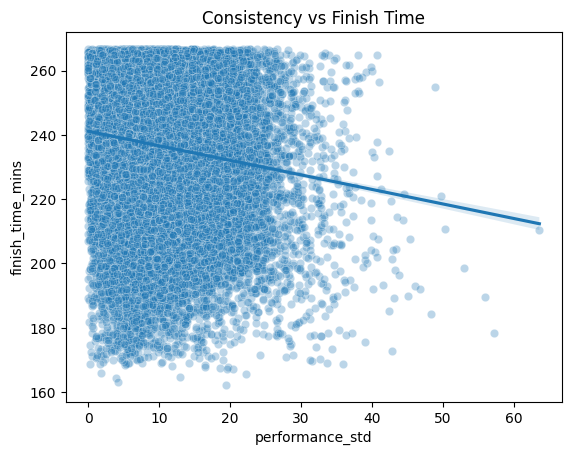

In [16]:
plt.figure()
sns.scatterplot(x="performance_std", y="finish_time_mins", data=df_50km, alpha=0.3)
sns.regplot(x="performance_std", y="finish_time_mins", data=df_50km, scatter=False)
plt.title("Consistency vs Finish Time")
plt.show()

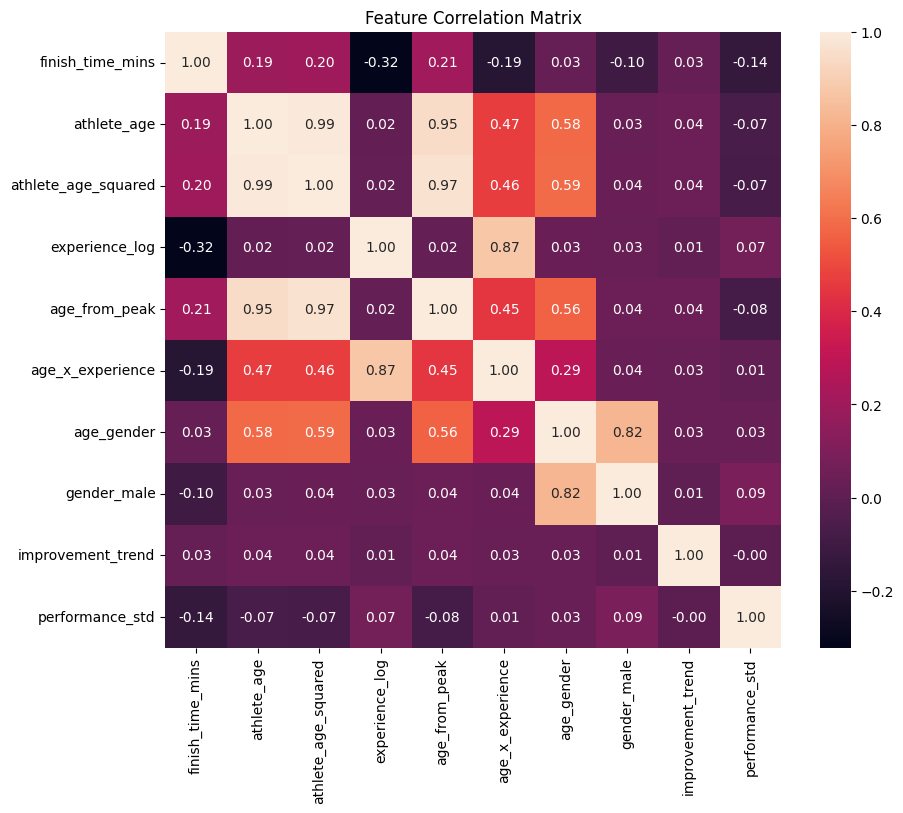

In [17]:
plt.figure(figsize=(10, 8))
corr = df_50km[[
    "finish_time_mins",
    "athlete_age",
    "athlete_age_squared",
    "experience_log",
    "age_from_peak",
    "age_x_experience",
    "age_gender",
    "gender_male",
    "improvement_trend",
    "performance_std"
]].corr()

target = "finish_time_mins"
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# 3 — MODELING
# ══════════════════════════════════════════════════════════════════════════════
# a. remove features at risk for multicollinearity
features = [
    "gender_male",
    "age_from_peak",
    "experience_log",
    "improvement_trend",
    "performance_std"
]
target = "finish_time_mins"
model_df = df_50km[features + [target, "Year of event"]].dropna()

#a. Time-based model split
train_df = model_df[model_df["Year of event"] <= 2015]
val_df   = model_df[(model_df["Year of event"] >= 2016) & (model_df["Year of event"] <= 2018)]
test_df  = model_df[model_df["Year of event"] >= 2019]

X_train, y_train = train_df[features], train_df[target]
X_val,   y_val   = val_df[features],   val_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 21071 | Val: 6897 | Test: 4540


In [19]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform
X_val_s   = scaler.transform(X_val)         # transform only
X_test_s  = scaler.transform(X_test)        # transform only

In [20]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  MAE:  {mae:.2f} mins")
    print(f"  RMSE: {rmse:.2f} mins")
    print(f"  R²:   {r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 1 — LINEAR (RIDGE) REGRESSION
# ══════════════════════════════════════════════════════════════════════════════
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

best_alpha, best_val_mae = 1.0, float("inf")
for alpha in [0.01, 0.1, 1, 10, 100]:
    m = Ridge(alpha=alpha).fit(X_train_s, y_train)
    mae = mean_absolute_error(y_val, m.predict(X_val_s))
    if mae < best_val_mae:
        best_val_mae, best_alpha = mae, alpha

ridge_final = Ridge(alpha=best_alpha).fit(X_train_s, y_train)
results.append(evaluate("Ridge Regression", y_test, ridge_final.predict(X_test_s)))

coef_df = pd.DataFrame({"feature": features, "coef": ridge_final.coef_})
print(coef_df.sort_values("coef", key=abs, ascending=False))


────────────────────────────────────────
  Ridge Regression
  MAE:  16.40 mins
  RMSE: 20.38 mins
  R²:   0.0934
             feature      coef
1      age_from_peak  5.651921
2     experience_log -3.674932
0        gender_male -2.379866
4    performance_std -1.468284
3  improvement_trend  0.112801


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 2 — REGRESSION TREE
# ══════════════════════════════════════════════════════════════════════════════
param_grid = {
    "max_depth":        [3, 4, 5, 6, 7],
    "min_samples_split":[2, 5, 10, 20, 50],     # min samples to split a node
    "min_samples_leaf": [1, 5, 10, 20, 30],     # min samples at a leaf
    "max_features":     [0.5, 0.7],  # features to consider per split
    "ccp_alpha":        [0.0, 0.001, 0.01, 0.1],  # pruning strength
}

keys, values = zip(*param_grid.items())
best_params, best_val_mae = {}, float("inf")

for combo in itertools.product(*values):
    params = dict(zip(keys, combo))
    m = DecisionTreeRegressor(**params, random_state=42).fit(X_train, y_train)
    mae = mean_absolute_error(y_val, m.predict(X_val))
    if mae < best_val_mae:
        best_val_mae, best_params = mae, params

print(f"Best val MAE: {best_val_mae:.2f}")
print(f"Best params: {best_params}")

tree_final = DecisionTreeRegressor(**best_params, random_state=42)
tree_final.fit(X_train, y_train)
results.append(evaluate(f"Regression Tree (tuned)", y_test, tree_final.predict(X_test)))

# Feature importances
imp_df = pd.DataFrame({"feature": features, "importance": tree_final.feature_importances_})
print(imp_df.sort_values("importance", ascending=False))

Best val MAE: 15.48
Best params: {'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_features': 0.5, 'ccp_alpha': 0.1}

────────────────────────────────────────
  Regression Tree (tuned)
  MAE:  16.46 mins
  RMSE: 20.49 mins
  R²:   0.0831
             feature  importance
1      age_from_peak    0.553045
2     experience_log    0.275389
0        gender_male    0.083640
4    performance_std    0.063972
3  improvement_trend    0.023954


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 3 — GRADIENT BOOSTING (sklearn GBM)
# ══════════════════════════════════════════════════════════════════════════════
best_params, best_val_mae = {}, float("inf")
for n_est in [100, 200, 300]:
    for lr in [0.01, 0.05, 0.1]:
        m = GradientBoostingRegressor(
            n_estimators=n_est, learning_rate=lr,
            max_depth=4, subsample=0.8, random_state=42
        ).fit(X_train, y_train)
        mae = mean_absolute_error(y_val, m.predict(X_val))
        if mae < best_val_mae:
            best_val_mae, best_params = mae, {"n_estimators": n_est, "learning_rate": lr}

gbm_final = GradientBoostingRegressor(**best_params, max_depth=4, subsample=0.8, random_state=42)
gbm_final.fit(X_train, y_train)
results.append(evaluate(f"Gradient Boosting {best_params}", y_test, gbm_final.predict(X_test)))


────────────────────────────────────────
  Gradient Boosting {'n_estimators': 300, 'learning_rate': 0.05}
  MAE:  16.26 mins
  RMSE: 20.31 mins
  R²:   0.0994


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 4 — K-NEAREST NEIGHBORS
# ══════════════════════════════════════════════════════════════════════════════
best_params, best_val_mae = {}, float("inf")

for k in [3, 5, 7, 10, 15, 20, 25, 30]:
    for weights in ["uniform", "distance"]:   # uniform = all neighbours equal
        for metric in ["euclidean", "manhattan"]:  # distance calculation method
            m = KNeighborsRegressor(
                n_neighbors=k,
                weights=weights,
                metric=metric
            ).fit(X_train_s, y_train)  # KNN NEEDS scaling — use X_train_s not X_train
            mae = mean_absolute_error(y_val, m.predict(X_val_s))
            if mae < best_val_mae:
                best_val_mae, best_params = mae, {
                    "n_neighbors": k,
                    "weights": weights,
                    "metric": metric
                }

knn_final = KNeighborsRegressor(**best_params)
knn_final.fit(X_train_s, y_train)
results.append(evaluate(f"KNN {best_params}", y_test, knn_final.predict(X_test_s)))


────────────────────────────────────────
  KNN {'n_neighbors': 30, 'weights': 'uniform', 'metric': 'manhattan'}
  MAE:  16.52 mins
  RMSE: 20.56 mins
  R²:   0.0768


How do these predictions compare to the mean?

In [27]:
mean_time = 240.45
baseline_preds = np.full(shape=y_test.shape, fill_value=mean_time)
results.append(evaluate("Mean Baseline", y_test, baseline_preds))


────────────────────────────────────────
  Mean Baseline
  MAE:  17.14 mins
  RMSE: 21.63 mins
  R²:   -0.0212


Each model is a slight increase over the mean, with gradient boosting slightly outperforming the rest